# Visualizing statistical relationships

📄 Source: https://seaborn.pydata.org/tutorial/relational.html

How do variables relate to each other, and how does that depend on other variables? This page uses three functions:

- **`relplot`**: figure-level (a `FacetGrid` + one of the two below)
- `scatterplot` (`kind="scatter"`, the default)
- `lineplot` (`kind="line"`)

A 2-D plot can show up to **three more variables** through the semantics `hue`, `size` and `style`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
np.random.seed(sum(map(ord, "relational")))   # the docs' seed, so bootstrapped CIs match
print("seaborn", sns.__version__)

seaborn 0.13.2


## Relating variables with scatter plots

A scatter plot shows the joint distribution of two numeric variables: one point per observation. It's the default `kind` of `relplot`:

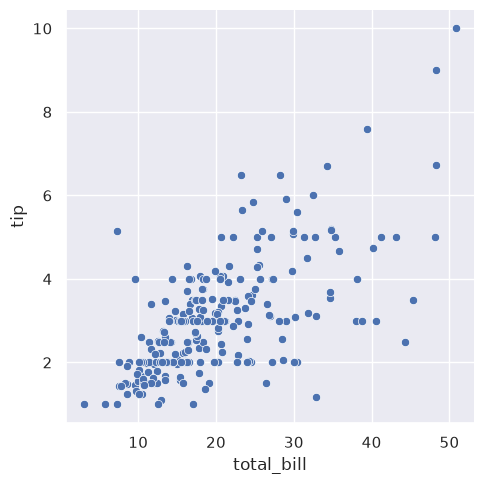

In [2]:
tips = sns.load_dataset("tips")
sns.relplot(data=tips, x="total_bill", y="tip")

**hue semantic**: colour the points by a third variable.

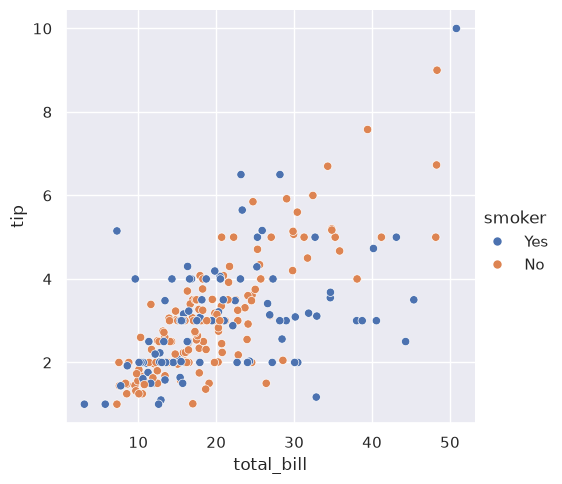

In [3]:
sns.relplot(data=tips, x="total_bill", y="tip", hue="smoker")

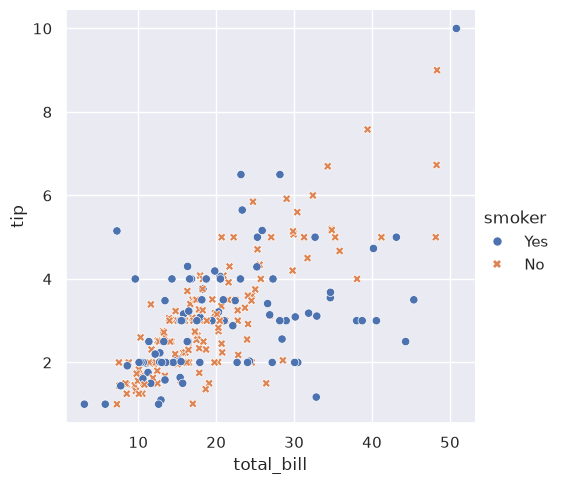

In [4]:
# Different marker per class too: clearer, and more accessible
sns.relplot(
    data=tips,
    x="total_bill", y="tip", hue="smoker", style="smoker"
)

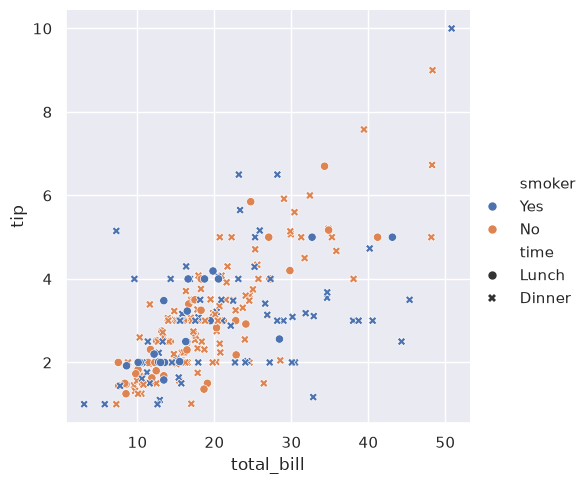

In [5]:
# Four variables: hue and style map DIFFERENT columns (careful: the eye is less sensitive to shape than colour)
sns.relplot(
    data=tips,
    x="total_bill", y="tip", hue="smoker", style="time",
)

Categorical `hue` → qualitative palette. **Numeric** `hue` → sequential palette:

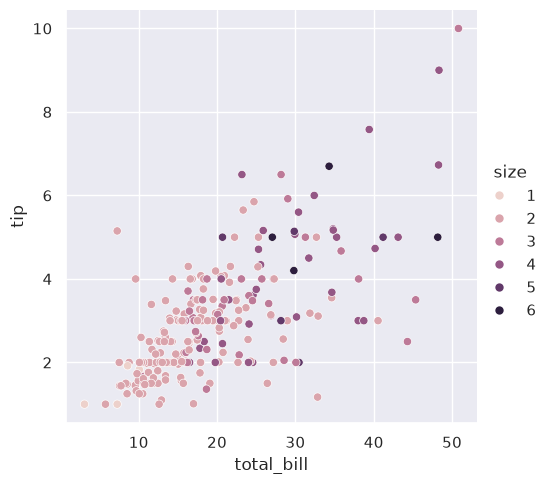

In [6]:
sns.relplot(
    data=tips, x="total_bill", y="tip", hue="size",
)

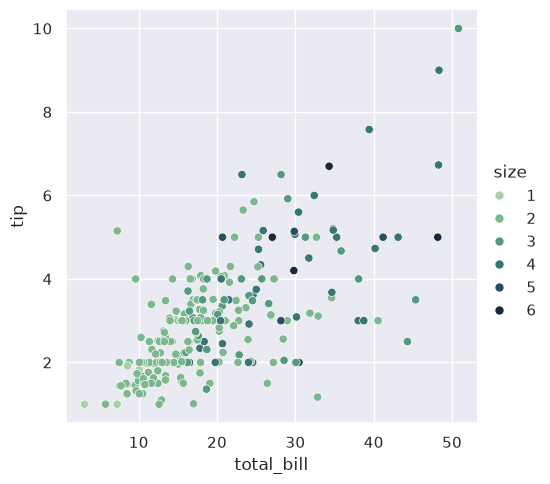

In [7]:
# Customise the palette, here with the cubehelix string interface ("ch:...")
sns.relplot(
    data=tips,
    x="total_bill", y="tip",
    hue="size", palette="ch:r=-.5,l=.75"   # r = rotation, l = lightness
)

**size semantic**: the point's size.

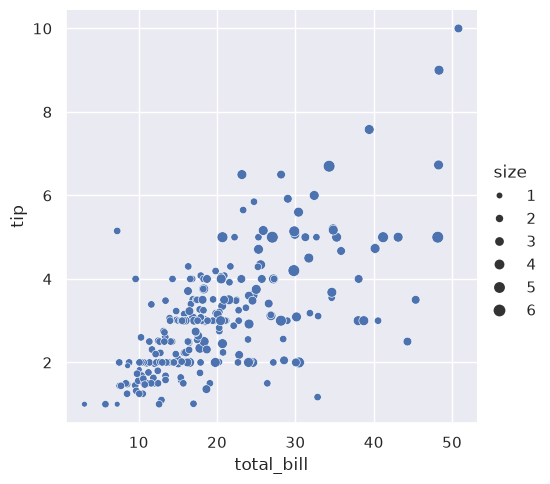

In [8]:
sns.relplot(data=tips, x="total_bill", y="tip", size="size")

Unlike `plt.scatter`, the raw value is **not** used as the area: the data range is normalised into an area range, which you can set:

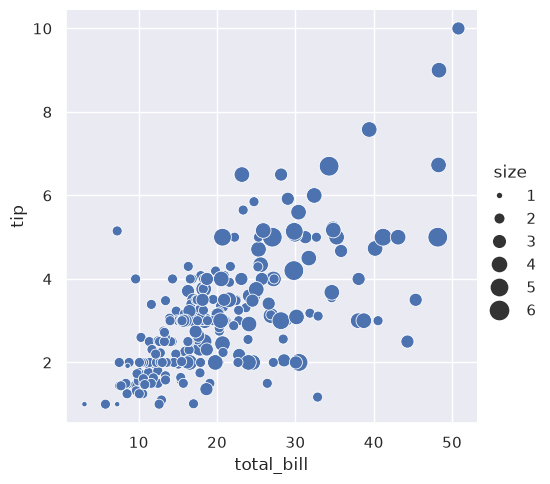

In [9]:
sns.relplot(
    data=tips, x="total_bill", y="tip",
    size="size", sizes=(15, 200)   # smallest and largest marker area
)

## Emphasizing continuity with line plots

When one variable is time (or similarly continuous), a line plot is better. Use `lineplot` or `relplot(kind="line")`:

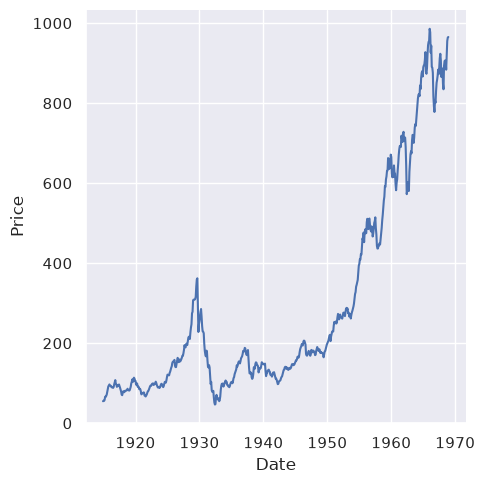

In [10]:
dowjones = sns.load_dataset("dowjones")
sns.relplot(data=dowjones, x="Date", y="Price", kind="line")

### Aggregation and representing uncertainty

When there are **several measurements per x value**, seaborn plots the **mean** and a **95% confidence interval** around it:

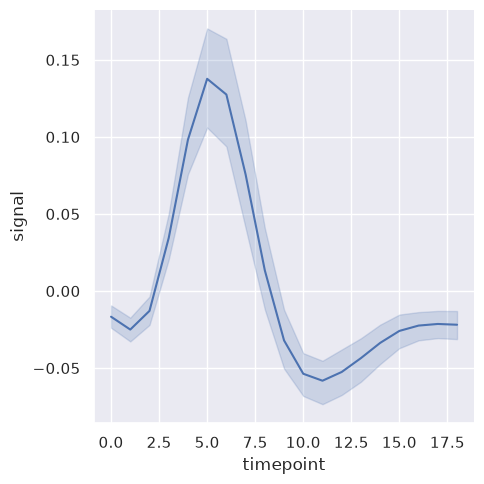

In [11]:
fmri = sns.load_dataset("fmri")
sns.relplot(data=fmri, x="timepoint", y="signal", kind="line")

The CI is computed by **bootstrapping** (resampling the data many times, like the Month 1 bootstrap work). It can be slow on big data, so you can turn it off:

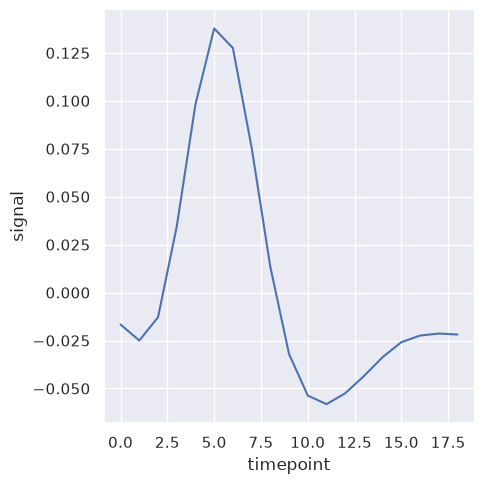

In [12]:
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", errorbar=None,   # no band
)

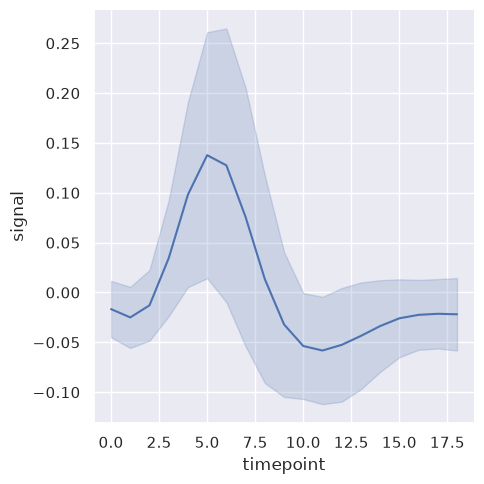

In [13]:
# Or show the SPREAD of the data (standard deviation) instead of the uncertainty of the mean
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", errorbar="sd",
)

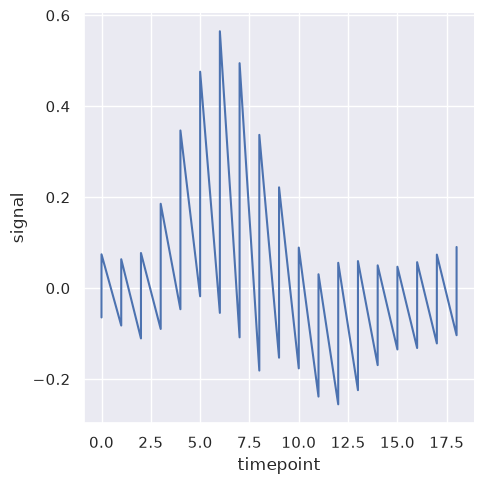

In [14]:
# Turn off aggregation completely: looks strange when there are many observations per x
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal",
    estimator=None,
)

### Plotting subsets of data with semantic mappings

`lineplot` has the same `hue`/`size`/`style` API as `scatterplot`. Semantics also decide **how the data are aggregated**: a `hue` with two levels → two lines, two bands.

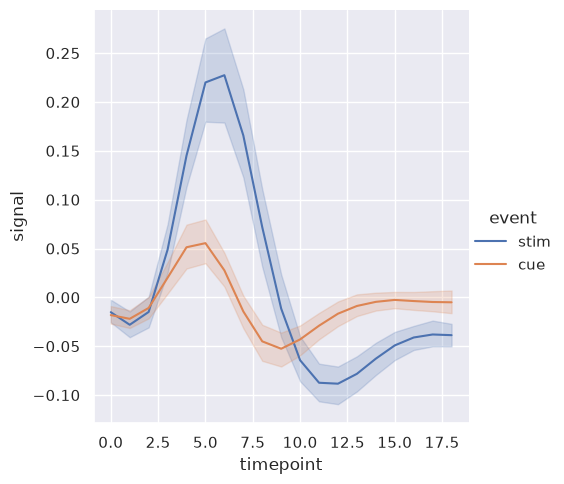

In [15]:
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", hue="event",
)

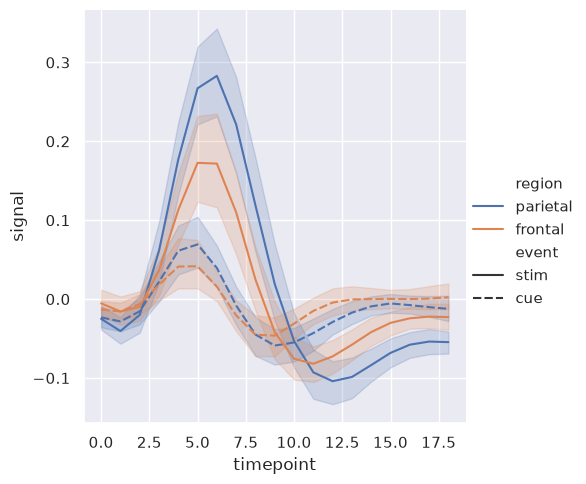

In [16]:
# style on a line plot = dash pattern
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal",
    hue="region", style="event",
)

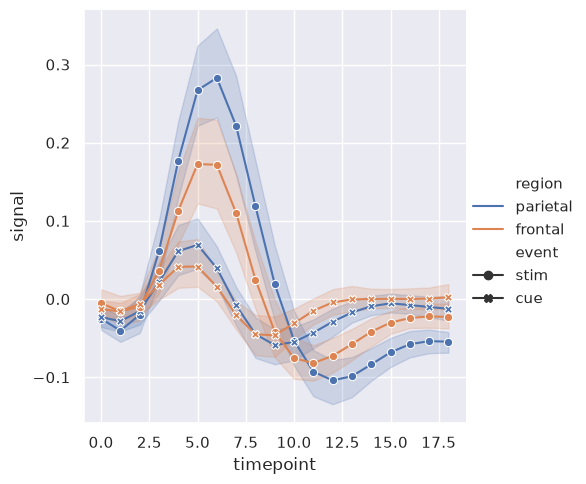

In [17]:
# Or identify subsets by markers instead of dashes
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", hue="region", style="event",
    dashes=False, markers=True,
)

Be careful with many semantics. But mapping **one** variable to both colour and style is good for black-and-white printing and colour-blind readers:

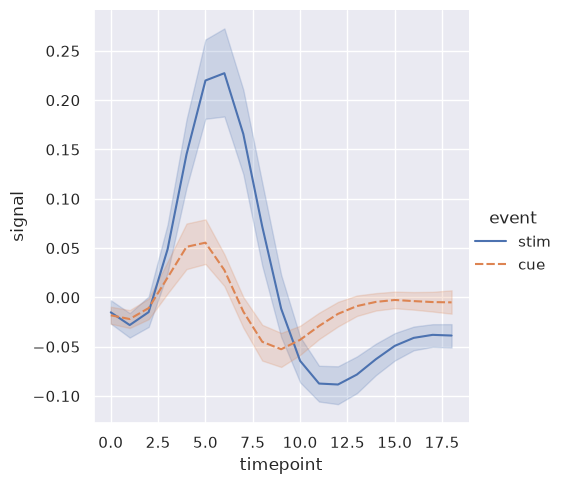

In [18]:
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", hue="event", style="event",
)

**Repeated measures**: draw each sampling unit (subject) as its own line without adding it to the legend, using `units=`:

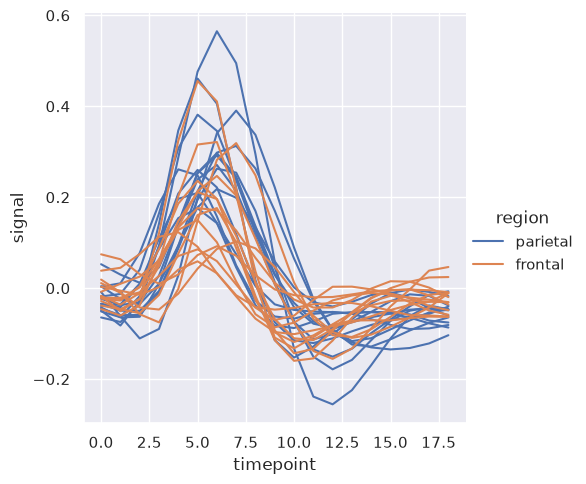

In [19]:
sns.relplot(
    data=fmri.query("event == 'stim'"), kind="line",
    x="timepoint", y="signal", hue="region",
    units="subject", estimator=None,   # one line per subject, no averaging
)

The colormap and legend depend on whether `hue` is categorical or **numeric**:

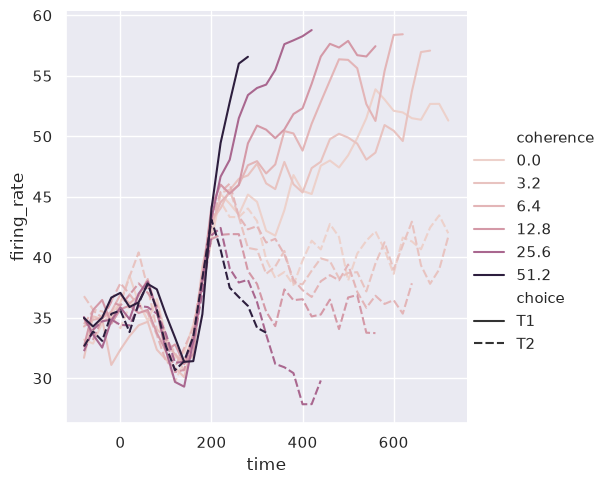

In [20]:
dots = sns.load_dataset("dots").query("align == 'dots'")
sns.relplot(
    data=dots, kind="line",
    x="time", y="firing_rate",
    hue="coherence", style="choice",
)

Here `coherence` levels are log-spaced, so a linear colour scale represents them poorly. Pass specific colours (list or dict):

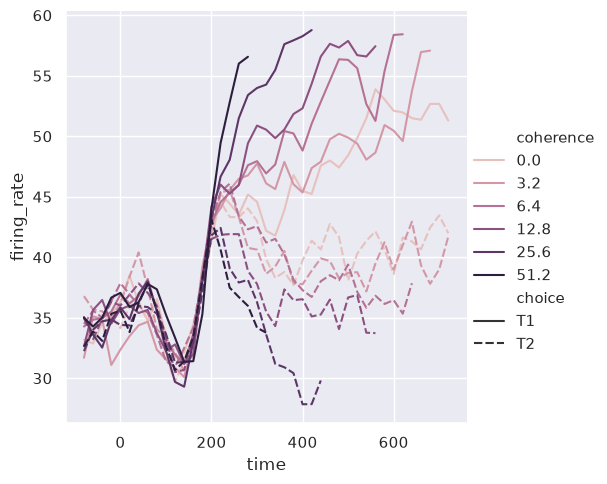

In [21]:
palette = sns.cubehelix_palette(light=.8, n_colors=6)   # 6 colours, one per coherence level
sns.relplot(
    data=dots, kind="line",
    x="time", y="firing_rate",
    hue="coherence", style="choice", palette=palette,
)

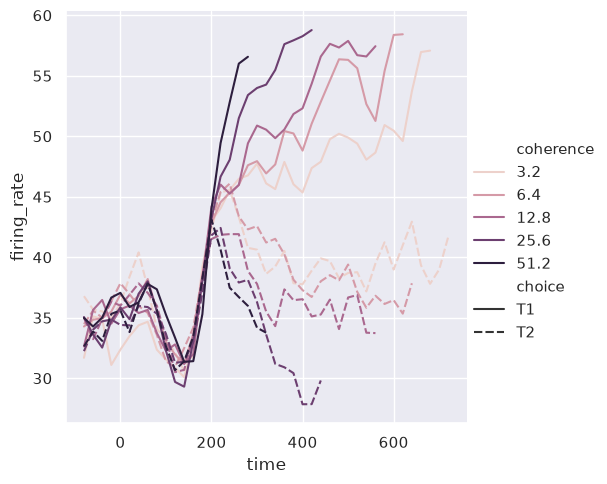

In [22]:
# ...or change how the colormap is normalised (log scale)
from matplotlib.colors import LogNorm
palette = sns.cubehelix_palette(light=.7, n_colors=6)
sns.relplot(
    data=dots.query("coherence > 0"), kind="line",   # log needs values > 0
    x="time", y="firing_rate",
    hue="coherence", style="choice",
    hue_norm=LogNorm(),
)

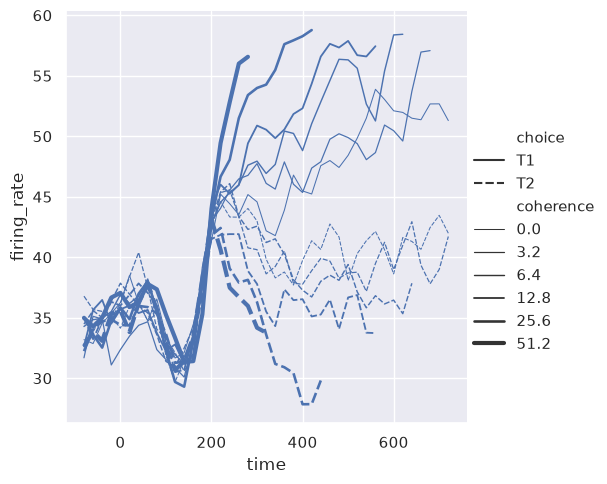

In [23]:
# size on a line plot = line width
sns.relplot(
    data=dots, kind="line",
    x="time", y="firing_rate",
    size="coherence", style="choice",
)

`size` can map a categorical variable too, but you can only really tell "thick" vs "thin". For very wiggly lines, width can still read better than dashes:

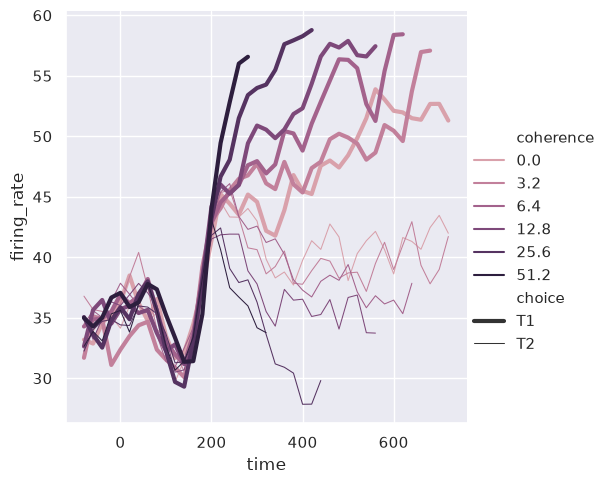

In [24]:
sns.relplot(
    data=dots, kind="line",
    x="time", y="firing_rate",
    hue="coherence", size="choice", palette=palette,
)

### Controlling sorting and orientation

`lineplot` sorts by `x` before drawing (it assumes y = f(x)). Turn that off to connect points in data order:

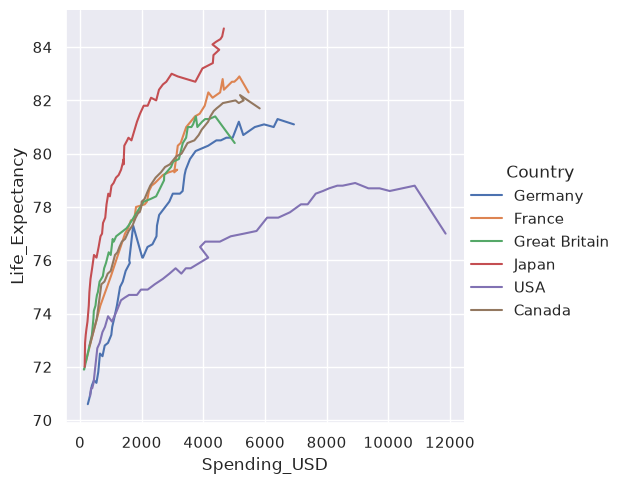

In [25]:
healthexp = sns.load_dataset("healthexp").sort_values("Year")
sns.relplot(
    data=healthexp, kind="line",
    x="Spending_USD", y="Life_Expectancy", hue="Country",
    sort=False   # keep the year order: each line traces a country through time
)

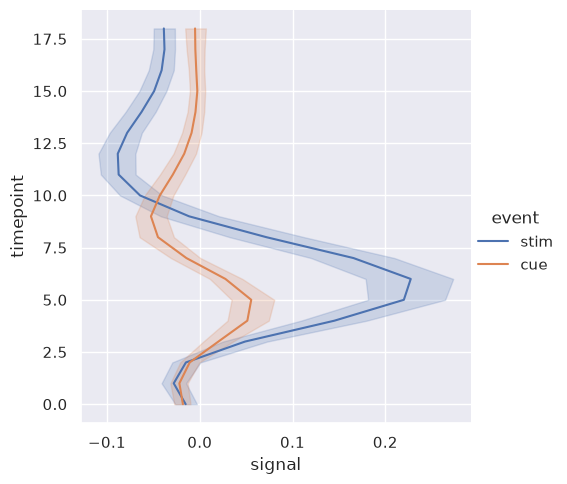

In [26]:
# Sort (and aggregate) along y instead
sns.relplot(
    data=fmri, kind="line",
     x="signal", y="timepoint", hue="event",
    orient="y",
)

## Showing multiple relationships with facets

Many semantics on one plot gets hard to read. Often better: **several plots**. Since `relplot` uses `FacetGrid`, facet on a variable with `col=` / `row=`:

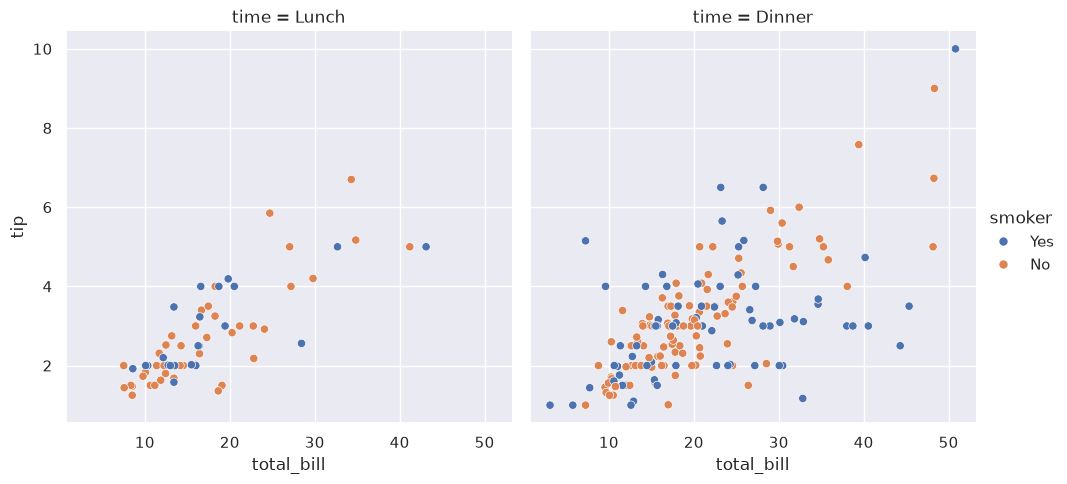

In [27]:
sns.relplot(
    data=tips,
    x="total_bill", y="tip", hue="smoker", col="time",   # one panel per time
)

Two variables: one on columns, one on rows. With more panels, shrink each one (size is set **per facet** with `height`/`aspect`):

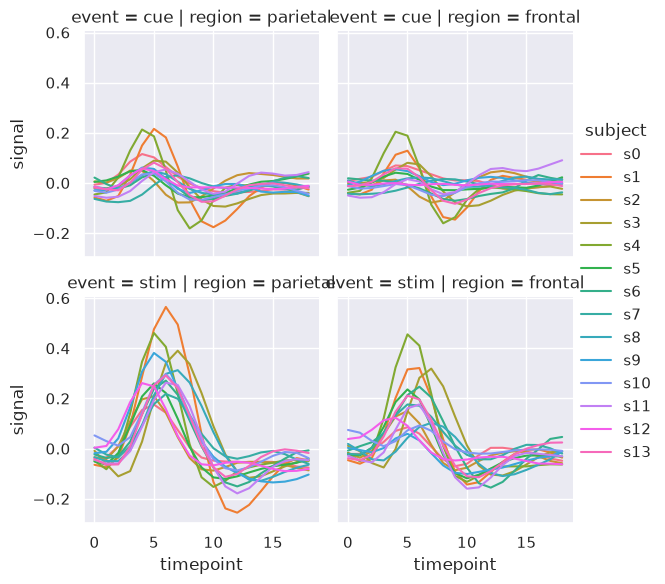

In [28]:
subject_number = fmri["subject"].str[1:].astype(int)   # "s13" -> 13, to sort subjects numerically
fmri = fmri.iloc[subject_number.argsort()]
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", hue="subject",
    col="region", row="event", height=3,
    estimator=None
)

Many levels of one variable: facet on columns and **wrap** into rows:

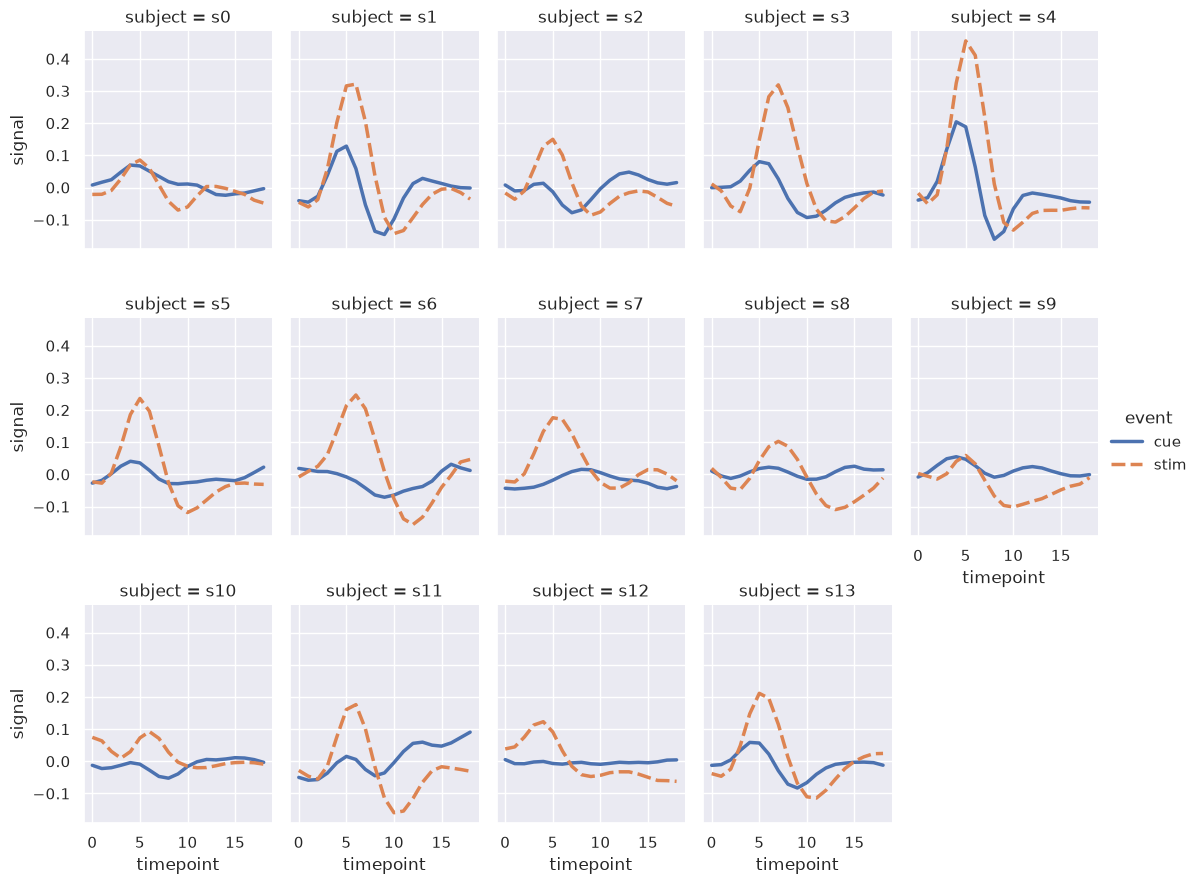

In [29]:
sns.relplot(
    data=fmri.query("region == 'frontal'"), kind="line",
    x="timepoint", y="signal", hue="event", style="event",
    col="subject", col_wrap=5,             # 5 panels per row
    height=3, aspect=.75, linewidth=2.5,
)

These "lattice" plots / **small multiples** make it easy to see the overall pattern and the deviations from it. **Several simple plots usually beat one complex plot.**

## Key takeaways

- `relplot(data=, x=, y=, hue=, size=, style=, col=, row=, kind="scatter"|"line")`.
- Line plots aggregate repeated x values: mean + **bootstrapped 95% CI** by default. `errorbar=None` / `"sd"`; `estimator=None` to stop aggregating; `units=` for one line per unit.
- Numeric `hue` → sequential palette; control it with `palette=` or `hue_norm=`.
- Map one variable to both `hue` and `style` for accessibility.
- Prefer facets (`col`, `row`, `col_wrap`) over piling semantics into one plot.